In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    # MNE 3D in-notebook static backend
# text svg

Using notebook 3d backend.


In [3]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'PhonemeSequence', 
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        'SentenceRep'
        ]

ref = 'bipolar'

hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='zscore',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'

HGAs.head()

100%|██████████| 1169/1169 [02:20<00:00,  8.30it/s]


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0019_ROG1-2,-0.107115,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,20.731562,-95.433053,-4.406237
1,-1.0,D0019_ROG2-3,-0.100700,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,18.712896,-94.417750,6.523434
2,-1.0,D0019_ROG4-5,-0.087711,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_G_occipital_sup,sOccG,R,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG6-7,-0.077369,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,21.415317,-87.142845,15.405992
4,-1.0,D0019_ROG7-8,-0.046683,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,31.738807,-94.023646,-5.934703


In [4]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 733952
PIC electrode count: 757632


,time,channel,value,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,-1.0,D0019_ROG1-2,-0.107115,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,20.731562,-95.433053,-4.406237
1,-1.0,D0019_ROG2-3,-0.100700,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,18.712896,-94.417750,6.523434
2,-1.0,D0019_ROG4-5,-0.087711,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_G_occipital_sup,sOccG,R,16.298644,-91.860079,29.446276
3,-1.0,D0019_ROG6-7,-0.077369,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,21.415317,-87.142845,15.405992
4,-1.0,D0019_ROG7-8,-0.046683,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,31.738807,-94.023646,-5.934703


In [5]:
# drop columns
cords = HGAs.copy().drop(columns=["time","value"]).drop_duplicates()
cords.head()

,channel,mask,subject,description,task,phase,modality,label,roi,hemi,x,y,z
0,D0019_ROG1-2,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,20.731562,-95.433053,-4.406237
1,D0019_ROG2-3,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,18.712896,-94.417750,6.523434
2,D0019_ROG4-5,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_G_occipital_sup,sOccG,R,16.298644,-91.860079,29.446276
3,D0019_ROG6-7,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,21.415317,-87.142845,15.405992
4,D0019_ROG7-8,False,D0019,Repeat,PhonemeSequence,go,sound,ctx_rh_Pole_occipital,OPC,R,31.738807,-94.023646,-5.934703


In [6]:
pick = cords[(cords.roi=='AIC') | (cords.label.str.contains('Opercular')) & (cords.hemi=='L')]

# Find subjects that have both IFG and AIC
pick_subjects = pick.groupby('subject')['roi'].apply(lambda x: set(x) >= {'IFG', 'AIC'})
in_both = pick_subjects[pick_subjects].index.tolist()

# Filter data for subjects with both ROIs
pick = pick[pick.subject.isin(in_both)]

# Create MultiIndex DataFrame with each electrode as separate row
both = pick.set_index(['subject','task','roi']).sort_index()

# Display the MultiIndex DataFrame
both.head()

channel   mask description  phase modality  \
subject task         roi                                                    
D0032   LexicalDelay AIC  D0032_LAI1-2  False    Decision  delay    sound   
                     AIC  D0032_LAI3-4  False    Decision  delay    sound   
                     AIC  D0032_LAI4-5  False    Decision  delay    sound   
                     AIC  D0032_LAI4-5   True    Decision  delay    sound   
                     AIC  D0032_LAI1-2  False      Repeat  delay    sound   

                                                 label hemi          x  \
subject task         roi                                                 
D0032   LexicalDelay AIC        ctx_lh_G_insular_short    L -37.007849   
                     AIC        ctx_lh_G_insular_short    L -37.042906   
                     AIC  ctx_lh_S_circular_insula_sup    L -37.060344   
                     AIC  ctx_lh_S_circular_insula_sup    L -37.060344   
                     AIC        ctx_lh_G_insular_short    L -37.007849   

                                  y         z  
subject task         roi                       
D0032   LexicalDelay AIC   9.260216 -8.201160  
                     AIC  10.072254 -0.909710  
                     AIC  10.755693  2.733611  
                     AIC  10.755693  2.733611  
                     AIC   9.260216 -8.201160

In [7]:
both.index.get_level_values('subject').unique()   # unique subjects

Index(['D0032', 'D0035', 'D0040', 'D0064', 'D0067', 'D0094', 'D0096', 'D0106',
       'D0121', 'D0122', 'D0125'],
      dtype='object', name='subject')

In [8]:
both.xs('D0125', level='subject').channel.unique()

array(['D0125_LIA3-4', 'D0125_LIA4-5', 'D0125_LIA7-8', 'D0125_LTAS2-3',
       'D0125_LTAS3-4', 'D0125_LIA5-6', 'D0125_LIA6-7'], dtype=object)

# Take the channel out

In [9]:
# define the list of address
LEXICAL_DELAY_PT = '/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/'
PHONEME_PT = '/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/'
LEXICAL_NODELAY_PT = '/cwork/ns458/BIDS-1.0_LexicalDecRepNoDelay/BIDS/'
PICTURE_NAMING_PT = '/cwork/ns458/BIDS-1.3_PictureNaming/BIDS/'
SENTENCE_REP_PT = '/cwork/ns458/BIDS-1.4_SentenceRep/BIDS/'

In [23]:
import re

sub = 'D0106'
phase = 'Response'
# Get channels for AIC and IFG separately
aic_chns = both.xs((sub, 'AIC'), level=['subject', 'roi'])['channel'].unique().tolist()
ifg_chns = both.xs((sub, 'IFG'), level=['subject', 'roi'])['channel'].unique().tolist()

# Extract shank prefixes from ROI channels (strip trailing digit-digit pattern)
def get_shank_prefix(ch_name):
    """E.g., 'D0040_L1IF2-3' -> 'D0040_L1IF'"""
    return re.sub(r'\d+-\d+$', '', ch_name)

roi_chns = aic_chns + ifg_chns
shank_prefixes = set(get_shank_prefix(ch) for ch in roi_chns)

raw_pt = BIDSPath(
    root=os.path.join(PICTURE_NAMING_PT, 'derivatives', 'epoch(bipolar)'),
    datatype='epoch(band)(zscore)',
    subject=sub,
    suffix='highgamma',
    processing=phase,
    extension='.h5',
    check=False
)

raw_pt = raw_pt.match()[0]
raw_epo = mne.read_epochs(raw_pt, preload=True, verbose='error')

# Pick all channels belonging to the same shanks as ROI channels
all_ch_names = raw_epo.ch_names
shank_chns = [ch for ch in all_ch_names if get_shank_prefix(ch) in shank_prefixes]

raw_epo = raw_epo.pick_channels(shank_chns, verbose='error')
print(f"AIC channels: {aic_chns}")
print(f"IFG channels: {ifg_chns}")
print(f"Shank prefixes: {shank_prefixes}")
print(f"All shank channels ({len(shank_chns)}): {shank_chns}")

AIC channels: ['D0106_LAI1-2', 'D0106_LAI2-3', 'D0106_LAI3-4', 'D0106_LAI7-8', 'D0106_LAI8-9', 'D0106_LAI9-10', 'D0106_LTAS1-2', 'D0106_LTAS2-3']
IFG channels: ['D0106_LTAS3-4', 'D0106_LTAS4-5']
Shank prefixes: {'D0106_LTAS', 'D0106_LAI'}
All shank channels (22): ['D0106_LAI1-2', 'D0106_LAI2-3', 'D0106_LAI3-4', 'D0106_LAI4-5', 'D0106_LAI5-6', 'D0106_LAI6-7', 'D0106_LAI7-8', 'D0106_LAI8-9', 'D0106_LAI9-10', 'D0106_LAI10-11', 'D0106_LAI11-12', 'D0106_LAI12-13', 'D0106_LAI13-14', 'D0106_LAI14-15', 'D0106_LAI15-16', 'D0106_LAI16-17', 'D0106_LTAS1-2', 'D0106_LTAS2-3', 'D0106_LTAS3-4', 'D0106_LTAS4-5', 'D0106_LTAS5-6', 'D0106_LTAS6-7']


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/D106/label/lh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-14 13:35:50.612 (9044.055s) [    7F5CFADBF440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x1b7ef970): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-14 13:35:50.717 (9044.159s) [    7F5CFADBF440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x1b7ef970): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: 

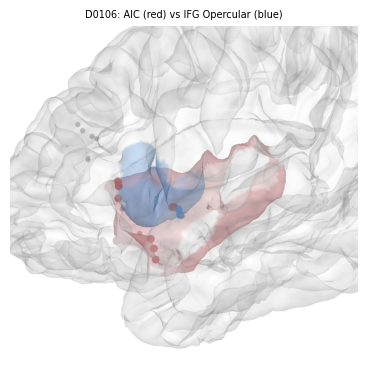

In [24]:
import pyvista as pv
from mne.viz import Brain
from scipy.spatial import cKDTree

# Subject recon name (D0040 -> D40, D0106 -> D106)
recon_sub = 'D' + str(int(sub[1:]))

# Get electrode positions from montage (in MRI surface RAS)
montage = raw_epo.get_montage()
pos = montage.get_positions()['ch_pos']  # dict: ch_name -> (x, y, z) in meters

# Filter channel lists to only those present in the montage with finite coordinates
avail = {ch for ch, xyz in pos.items() if np.all(np.isfinite(xyz))}
aic_chns_valid = [ch for ch in aic_chns if ch in avail]
ifg_chns_valid = [ch for ch in ifg_chns if ch in avail]
shank_chns_valid = [ch for ch in shank_chns if ch in avail]

# Classify all shank channels into AIC, IFG, or other
aic_set = set(aic_chns_valid)
ifg_set = set(ifg_chns_valid)
other_chns = [ch for ch in shank_chns_valid if ch not in aic_set and ch not in ifg_set]

# MNE montage is in meters, FreeSurfer surface is in mm
aic_coords = np.array([pos[ch] for ch in aic_chns_valid]) * 1000
ifg_coords = np.array([pos[ch] for ch in ifg_chns_valid]) * 1000
other_coords = np.array([pos[ch] for ch in other_chns]) * 1000

# Load individual pial surface for projection
lh_pial_path = f"{recon_dir}/{recon_sub}/surf/lh.pial"
lh_pial_coords, _ = mne.read_surface(lh_pial_path)
lh_tree = cKDTree(lh_pial_coords)

# Read parcellation labels (use surf_name='pial' since lh.white is missing)
labels = mne.read_labels_from_annot(
    subject=recon_sub, parc='aparc.a2009s',
    hemi='lh', subjects_dir=recon_dir, surf_name='pial'
)

# Define region patterns
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins',
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']
opercular_pattern = 'G_front_inf-Opercular'

# Compute focal point: center of insula + opercular vertices
focal_vertices = []
for lab in labels:
    if any(p in lab.name for p in insula_patterns) or opercular_pattern in lab.name:
        focal_vertices.extend(lab.vertices)
focal_center = lh_pial_coords[focal_vertices].mean(axis=0)

# Create Brain on individual subject (left hemisphere only)
brain = Brain(
    recon_sub, subjects_dir=recon_dir, surf="pial",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(800, 800)
)

# Add region labels with visible but translucent shading
for lab in labels:
    if any(p in lab.name for p in insula_patterns):
        brain.add_label(lab, borders=False, color=red, alpha=0.5)
    elif opercular_pattern in lab.name:
        brain.add_label(lab, borders=False, color=blue, alpha=0.5)

# Project electrodes onto pial surface and add as spheres
def add_electrodes(brain, coords, color, tree, pial_coords, size=15, opacity=1.0):
    _, indices = tree.query(coords)
    proj = pial_coords[indices]
    cloud = pv.PolyData(proj)
    brain._renderer.plotter.add_mesh(
        cloud, render_points_as_spheres=True,
        point_size=size, color=color, lighting=False, opacity=opacity,
    )

# Non-ROI shank electrodes in gray (smaller, semi-transparent)
if len(other_coords) > 0:
    add_electrodes(brain, other_coords, 'gray', lh_tree, lh_pial_coords, size=12, opacity=0.6)
# ROI electrodes highlighted (larger, fully opaque)
if len(aic_coords) > 0:
    add_electrodes(brain, aic_coords, red, lh_tree, lh_pial_coords, size=18)
if len(ifg_coords) > 0:
    add_electrodes(brain, ifg_coords, blue, lh_tree, lh_pial_coords, size=18)

# Set view centered on insula + opercular region
brain.show_view(azimuth=180, elevation=90, distance=200, focalpoint=focal_center)

fig, ax = plt.subplots(figsize=(10*cm, 10*cm))
ax.imshow(brain.screenshot(mode="rgb"))
ax.axis("off")
ax.set_title(f"{sub}: AIC (red) vs IFG Opercular (blue)", fontsize=fontsize)
brain.close()
plt.tight_layout()

Reading labels from parcellation...


   read 75 labels from /cwork/ns458/ECoG_Recon/D106/label/lh.aparc.a2009s.annot


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-14 13:35:56.051 (9049.494s) [    7F5CFADBF440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x1b73fbd0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-02-14 13:35:56.126 (9049.568s) [    7F5CFADBF440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x1b73fbd0): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: 

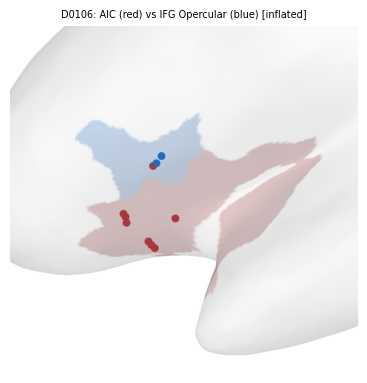

In [25]:
import pyvista as pv
from mne.viz import Brain
from scipy.spatial import cKDTree

# Subject recon name (D0040 -> D40, D0106 -> D106)
recon_sub = 'D' + str(int(sub[1:]))

# Get electrode positions from montage (in MRI surface RAS)
montage = raw_epo.get_montage()
pos = montage.get_positions()['ch_pos']  # dict: ch_name -> (x, y, z) in meters
# MNE montage is in meters, FreeSurfer surface is in mm
aic_coords = np.array([pos[ch] for ch in aic_chns]) * 1000
ifg_coords = np.array([pos[ch] for ch in ifg_chns]) * 1000

# Load pial surface to find nearest vertices for electrodes
lh_pial_path = f"{recon_dir}/{recon_sub}/surf/lh.pial"
lh_pial_coords, _ = mne.read_surface(lh_pial_path)
lh_pial_tree = cKDTree(lh_pial_coords)

# Load inflated surface for visualization coordinates
lh_inf_path = f"{recon_dir}/{recon_sub}/surf/lh.inflated"
lh_inf_coords, _ = mne.read_surface(lh_inf_path)

# Read parcellation labels
labels = mne.read_labels_from_annot(
    subject=recon_sub, parc='aparc.a2009s',
    hemi='lh', subjects_dir=recon_dir, surf_name='pial'
)

# Define region patterns
insula_patterns = ['G_insular_short', 'G_Ins_lg_and_S_cent_ins',
                   'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup']
opercular_pattern = 'G_front_inf-Opercular'

# Compute focal point on inflated surface: center of insula + opercular vertices
focal_vertices = []
for lab in labels:
    if any(p in lab.name for p in insula_patterns) or opercular_pattern in lab.name:
        focal_vertices.extend(lab.vertices)
focal_center = lh_inf_coords[focal_vertices].mean(axis=0)

# Create Brain with inflated surface
brain = Brain(
    recon_sub, subjects_dir=recon_dir, surf="inflated",
    hemi="lh", background="white", show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.2, size=(800, 800)
)

# Add region labels with visible but translucent shading
for lab in labels:
    if any(p in lab.name for p in insula_patterns):
        brain.add_label(lab, borders=False, color=red, alpha=0.5)
    elif opercular_pattern in lab.name:
        brain.add_label(lab, borders=False, color=blue, alpha=0.5)

# Project electrodes: find nearest pial vertex, then use inflated coords
def add_electrodes_inflated(brain, coords, color, pial_tree, inf_coords, size=15):
    _, indices = pial_tree.query(coords)
    proj = inf_coords[indices]
    cloud = pv.PolyData(proj)
    brain._renderer.plotter.add_mesh(
        cloud, render_points_as_spheres=True,
        point_size=size, color=color, lighting=False,
    )

add_electrodes_inflated(brain, aic_coords, red, lh_pial_tree, lh_inf_coords, size=18)
add_electrodes_inflated(brain, ifg_coords, blue, lh_pial_tree, lh_inf_coords, size=18)

# Set view centered on insula + opercular region
brain.show_view(azimuth=180, elevation=90, distance=200, focalpoint=focal_center)

fig, ax = plt.subplots(figsize=(10*cm, 10*cm))
ax.imshow(brain.screenshot(mode="rgb"))
ax.axis("off")
ax.set_title(f"{sub}: AIC (red) vs IFG Opercular (blue) [inflated]", fontsize=fontsize)
brain.close()
plt.tight_layout()

In [26]:
# Compute AIC×IFG cross-correlation on raw (non-averaged) epochs
import numpy as np
from scipy.signal import correlate

# 1) Reload raw epochs WITHOUT averaging/cropping
raw_epo_full = mne.read_epochs(raw_pt, preload=True, verbose='error')

# Use aic_chns + ifg_chns, filtering to only channels present in the file
pick_chns = [ch for ch in aic_chns + ifg_chns if ch in raw_epo_full.ch_names]
raw_epo_full = raw_epo_full.pick_channels(pick_chns, verbose='error')

# 2) Helper: z-scored cross-correlation (amplitude-invariant)
# Returns: xcorr shape (n_epochs, n_aic, n_ifg, n_lags), lag_times (seconds)
def compute_aic_ifg_xcorr_z(epochs, aic_chns, ifg_chns, max_lag_seconds=1.0):
    sfreq = epochs.info['sfreq']
    max_lag = int(round(max_lag_seconds * sfreq)) if max_lag_seconds is not None else None

    # data shapes: (n_epochs, n_chan, n_times)
    data_aic = epochs.get_data(picks=aic_chns)
    data_ifg = epochs.get_data(picks=ifg_chns)
    n_epo, n_aic, n_t = data_aic.shape
    _, n_ifg, _ = data_ifg.shape

    # z-score per epoch per channel (remove mean, divide by std)
    def zscore(x, axis=-1):
        m = x.mean(axis=axis, keepdims=True)
        s = x.std(axis=axis, keepdims=True)
        s[s == 0] = 1.0  # avoid division by zero
        return (x - m) / s

    data_aic_z = zscore(data_aic)
    data_ifg_z = zscore(data_ifg)

    # lag grid
    full_lags = np.arange(-n_t + 1, n_t)
    if max_lag is not None:
        keep = (full_lags >= -max_lag) & (full_lags <= max_lag)
    else:
        keep = slice(None)
    lags = full_lags[keep]
    lag_times = lags / sfreq

    # allocate
    xcorr = np.empty((n_epo, n_aic, n_ifg, lags.size), dtype=np.float64)

    # correlate z-scored signals; normalize by length to get Pearson-like scale
    norm = n_t  # optional: use np.sqrt(np.sum(x^2) * np.sum(y^2)) if you change padding
    for e in range(n_epo):
        for i in range(n_aic):
            for j in range(n_ifg):  
                c = correlate(data_aic_z[e, i], data_ifg_z[e, j], mode='full', method='auto')
                sign = np.sign(c[np.argmax(np.abs(c))])
                xcorr[e, i, j] = c[keep] / norm * sign
    return xcorr, lag_times

# Example: lag window ±1 s, z-scored (amplitude-invariant)
xcorr, lag_times = compute_aic_ifg_xcorr_z(raw_epo_full, aic_chns, ifg_chns, max_lag_seconds=1.0)
print('xcorr shape:', xcorr.shape)  # (n_epochs, n_aic, n_ifg, n_lags)
print('lag_times (s) range:', lag_times[0], 'to', lag_times[-1])

# square to convert to variance explained
xcorr = xcorr**2
xcorr = xcorr.mean(axis=0)  # if you want AIC×IFG×lag averaged across epochs

xcorr shape: (80, 8, 2, 257)
lag_times (s) range: -1.0 to 1.0


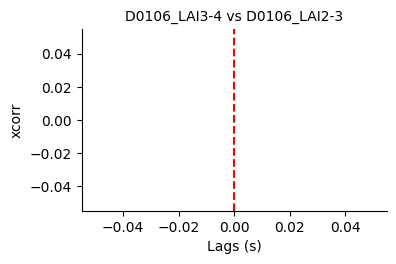

In [28]:
i = 2
j = 1

fig, ax = plt.subplots(figsize=(10*cm, 6*cm))
plt.plot(lag_times,xcorr[i,j])

vmin, vmax = np.percentile(xcorr, (1, 99))
# ax.set_ylim(0, 0.1)
sns.despine()
ax.set_xlabel('Lags (s)')
ax.set_ylabel('xcorr')

ax.set_title(f'{aic_chns[i]} vs {aic_chns[j]}', fontsize=10)
ax.axvline(x=0, color='r', linestyle='--')

#  Orthogonalization

In [29]:
ifg_channel =  ["D0106_LTAS3-4"]
insula_channel = ["D0106_LTAS2-3"]

raw_epo_ = raw_epo.copy()
xcorr, lag_times = compute_aic_ifg_xcorr_z(raw_epo_, insula_channel, ifg_channel, max_lag_seconds=1.0)

xcorr = xcorr.mean(axis=0)

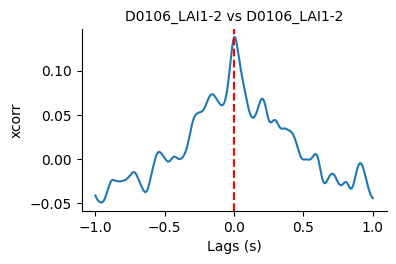

In [30]:
i = 0
j = 0

fig, ax = plt.subplots(figsize=(10*cm, 6*cm))
plt.plot(lag_times,xcorr[i,j])

vmin, vmax = np.percentile(xcorr, (1, 99))
# ax.set_ylim(0, 0.2)
sns.despine()
ax.set_xlabel('Lags (s)')
ax.set_ylabel('xcorr')

ax.set_title(f'{aic_chns[i]} vs {aic_chns[j]}', fontsize=10)
ax.axvline(x=0, color='r', linestyle='--')

In [31]:
ifg_xdata = raw_epo_.copy().pick(ifg_channel)._data.squeeze()
ins_xdata = raw_epo_.copy().pick(insula_channel)._data.squeeze()

In [32]:
import numpy as np

def orthogonalize(data_A, data_B):

    n_trials = data_A.shape[0]
    data_A_ortho = np.zeros_like(data_A)
    betas = np.zeros(n_trials)

    for i in range(n_trials):
        a_i = data_A[i, :]
        b_i = data_B[i, :]
        
        # 1. 计算该 trial 的回归系数 beta
        # 分母加个极小值 eps 防止除以 0
        beta = np.dot(a_i, b_i) / (np.dot(b_i, b_i) + 1e-10)
        
        # 2. 提取 A 中无法被 B 解释的部分
        data_A_ortho[i, :] = a_i - beta * b_i
        betas[i] = beta
        
    return data_A_ortho, betas

ins_independent, weights = orthogonalize(ins_xdata, ifg_xdata)

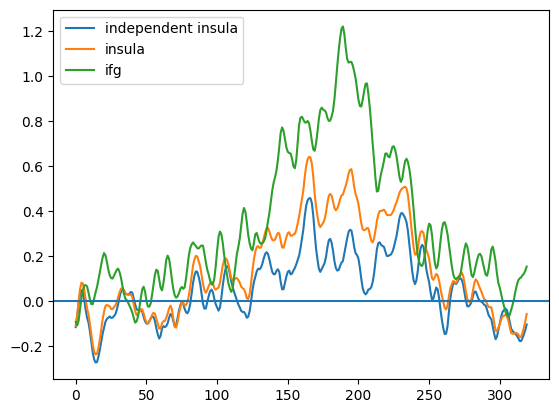

In [38]:
i = 14
fig, ax = plt.subplots()
ax.plot(ins_independent.mean(axis=0), label='independent insula')
ax.plot(ins_xdata.mean(axis=0), label='insula')
ax.plot(ifg_xdata.mean(axis=0), label='ifg')

ax.axhline(y=0)
ax.legend()

In [34]:
import numpy as np
from scipy.signal import correlate

def compute_aic_ifg_xcorr_z(data_aic, data_ifg, sfreq, max_lag_seconds=1.0):
    """Compute z-scored cross-correlation between AIC and IFG channel data.
    
    Args:
        data_aic: 3D array of shape (n_epochs, n_aic_channels, n_times)
        data_ifg: 3D array of shape (n_epochs, n_ifg_channels, n_times)
        sfreq: sampling frequency in Hz
        max_lag_seconds: maximum lag in seconds (default 1.0)
    
    Returns:
        xcorr: 4D array of shape (n_epochs, n_aic, n_ifg, n_lags) with variance-explained values
        lag_times: 1D array of lag times in seconds
    """
    # data shapes: (n_epochs, n_chan, n_times)
    n_epo, n_aic, n_t = data_aic.shape
    _, n_ifg, _ = data_ifg.shape

    max_lag = int(round(max_lag_seconds * sfreq)) if max_lag_seconds is not None else None

    # z-score per epoch per channel (remove mean, divide by std)
    def zscore(x, axis=-1):
        m = x.mean(axis=axis, keepdims=True)
        s = x.std(axis=axis, keepdims=True)
        s[s == 0] = 1.0  # avoid division by zero
        return (x - m) / s

    data_aic_z = zscore(data_aic)
    data_ifg_z = zscore(data_ifg)

    # lag grid
    full_lags = np.arange(-n_t + 1, n_t)
    if max_lag is not None:
        keep = (full_lags >= -max_lag) & (full_lags <= max_lag)
    else:
        keep = slice(None)
    lags = full_lags[keep]
    lag_times = lags / sfreq

    # allocate
    xcorr = np.empty((n_epo, n_aic, n_ifg, lags.size), dtype=np.float64)

    # correlate z-scored signals; normalize by length to get Pearson-like scale
    norm = n_t
    for e in range(n_epo):
        for i in range(n_aic):
            for j in range(n_ifg):  
                c = correlate(data_aic_z[e, i], data_ifg_z[e, j], mode='full', method='auto')
                sign = np.sign(c[np.argmax(np.abs(c))])
                xcorr[e, i, j] = c[keep] / norm * sign
    
    return xcorr, lag_times

# Example usage:
xcorr_after, lag_times = compute_aic_ifg_xcorr_z(ins_independent[:,np.newaxis,:], 
                                           ifg_xdata[:, np.newaxis,:], sfreq=128.0, max_lag_seconds=1.0)

xcorr_before, lag_times = compute_aic_ifg_xcorr_z(ins_xdata[:,np.newaxis,:], 
                                           ifg_xdata[:, np.newaxis,:], sfreq=128.0, max_lag_seconds=1.0)

print('xcorr shape:', xcorr.shape)  # (n_epochs, n_aic, n_ifg, n_lags)
print('lag_times (s) range:', lag_times[0], 'to', lag_times[-1])

# square to convert to variance explained
xcorr_after = xcorr_after**2
xcorr_after = xcorr_after.mean(axis=0)  # if you want AIC×IFG×lag averaged across epochs

xcorr_before = xcorr_before**2
xcorr_before = xcorr_before.mean(axis=0)  # if you want AIC×IFG×lag averaged across epochs

xcorr shape: (1, 1, 257)
lag_times (s) range: -1.0 to 1.0


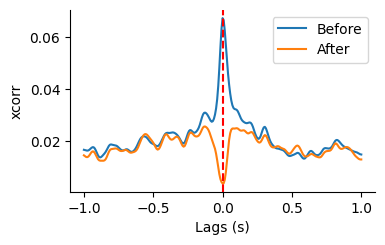

In [ ]:
i = 0
j = 0

fig, ax = plt.subplots(figsize=(10*cm, 6*cm))
ax.plot(lag_times,xcorr_before[i,j], label='Before')
plt.plot(lag_times,xcorr_after[i,j], label='After')

vmin, vmax = np.percentile(xcorr, (1, 99))
# ax.set_ylim(0, 0.2)
sns.despine()
ax.set_xlabel('Lags (s)')
ax.set_ylabel('xcorr')
plt.legend()
ax.axvline(x=0, color='r', linestyle='--')

# Load xcorr results

In [15]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        'PhonemeSequence', 
        'LexicalNoDelay',
        'LexicalDelay',
        'PictureNaming',
        'SentenceRep'
        ]

ref = 'bipolar'
xcorr_paths = []
for t in task:
    xcorr_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='xcorr',
            suffix='highgamma',
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
xcorrs = []
for path in tqdm(xcorr_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    xcorrs.append(df)

xcorrs = pd.concat(xcorrs)

# rename INS to 'Insula'
xcorrs.head()

100%|██████████| 796/796 [03:13<00:00,  4.11it/s]


,trial,source,target,source_roi,source_label,source_x,source_y,source_z,target_roi,target_label,target_x,target_y,target_z,peak_val,peak_lag_s,subject,phase,description,band,task
0,0,D0022_LPIF3-4,D0022_LMSF3-4,INS,ctx_lh_S_circular_insula_inf,-34.587586,-19.67704,-2.311079,MFG,ctx_lh_G_front_middle,-23.566958,57.766359,26.940067,0.018116,-0.2960,D0022,Go,Repeat,highgamma,PhonemeSequence
1,0,D0022_LPIF3-4,D0022_LMSF4-5,INS,ctx_lh_S_circular_insula_inf,-34.587586,-19.67704,-2.311079,MFG,ctx_lh_G_front_middle,-21.821305,53.991872,33.249195,0.013000,-0.4465,D0022,Go,Repeat,highgamma,PhonemeSequence
2,0,D0022_LPIF3-4,D0022_LAMF5-6,INS,ctx_lh_S_circular_insula_inf,-34.587586,-19.67704,-2.311079,MFG,ctx_lh_G_front_middle,-39.572375,31.169603,29.362010,0.014330,0.9775,D0022,Go,Repeat,highgamma,PhonemeSequence
3,0,D0022_LPIF3-4,D0022_LMIF2-3,INS,ctx_lh_S_circular_insula_inf,-34.587586,-19.67704,-2.311079,Put,Left-Putamen,-30.945483,-15.142778,-10.141665,0.015048,-0.5535,D0022,Go,Repeat,highgamma,PhonemeSequence
4,0,D0022_LPIF3-4,D0022_LMIF5-6,INS,ctx_lh_S_circular_insula_inf,-34.587586,-19.67704,-2.311079,HG,ctx_lh_S_temporal_transverse,-49.716957,-12.270617,-12.142812,0.017680,0.0680,D0022,Go,Repeat,highgamma,PhonemeSequence


In [16]:
xcorrs[xcorrs.target_roi=='IFG'].target_label.unique()

array(['ctx_lh_G_front_inf-Orbital', 'ctx_lh_G_front_inf-Opercular',
       'ctx_lh_G_front_inf-Triangul', 'ctx_rh_G_front_inf-Triangul',
       'ctx_rh_G_front_inf-Orbital', 'ctx_rh_G_front_inf-Opercular'],
      dtype=object)

In [17]:
oper_xcorrs = xcorrs[
                    (xcorrs.target_label.str.contains('Opercular')) 
                     & (xcorrs.target_label.str.contains('lh'))
                     & (xcorrs.source_label.str.contains('insular_short'))]

# oper_xcorrs = xcorrs[(xcorrs.target_roi.str.contains('PrG')) 
#                      & (xcorrs.target_label.str.contains('lh'))
#                      & (xcorrs.source_label.str.contains('insular_short'))]
oper_xcorrs.head()

,trial,source,target,source_roi,source_label,source_x,source_y,source_z,target_roi,target_label,target_x,target_y,target_z,peak_val,peak_lag_s,subject,phase,description,band,task
13,0,D0035_LAI1-2,D0035_LAI4-5,INS,ctx_lh_G_insular_short,-39.677537,8.522433,-4.664427,IFG,ctx_lh_G_front_inf-Opercular,-38.210179,9.940248,8.153676,0.010730,0.542480,D0035,Go,Repeat,highgamma,PhonemeSequence
34,0,D0035_LAI2-3,D0035_LAI4-5,INS,ctx_lh_G_insular_short,-39.738028,8.655055,-0.744315,IFG,ctx_lh_G_front_inf-Opercular,-38.210179,9.940248,8.153676,0.019864,-0.000488,D0035,Go,Repeat,highgamma,PhonemeSequence
97,1,D0035_LAI1-2,D0035_LAI4-5,INS,ctx_lh_G_insular_short,-39.677537,8.522433,-4.664427,IFG,ctx_lh_G_front_inf-Opercular,-38.210179,9.940248,8.153676,0.011708,0.475586,D0035,Go,Repeat,highgamma,PhonemeSequence
118,1,D0035_LAI2-3,D0035_LAI4-5,INS,ctx_lh_G_insular_short,-39.738028,8.655055,-0.744315,IFG,ctx_lh_G_front_inf-Opercular,-38.210179,9.940248,8.153676,0.016403,0.022949,D0035,Go,Repeat,highgamma,PhonemeSequence
181,2,D0035_LAI1-2,D0035_LAI4-5,INS,ctx_lh_G_insular_short,-39.677537,8.522433,-4.664427,IFG,ctx_lh_G_front_inf-Opercular,-38.210179,9.940248,8.153676,0.011169,-0.860840,D0035,Go,Repeat,highgamma,PhonemeSequence


In [18]:
oper_xcorrs.source.unique()

array(['D0035_LAI1-2', 'D0035_LAI2-3', 'D0094_LIA1-2', 'D0094_LIA2-3',
       'D0094_LIA3-4', 'D0032_LAI1-2', 'D0032_LAI3-4', 'D0096_LIA1-2',
       'D0096_LIA2-3', 'D0096_LIA3-4', 'D0096_LIA4-5', 'D0096_LIP3-4',
       'D0096_LIP4-5', 'D0106_LAI1-2', 'D0106_LAI2-3', 'D0106_LAI3-4',
       'D0106_LAI7-8', 'D0106_LTAS1-2', 'D0106_LTAS2-3', 'D0121_LTAS1-2',
       'D0121_LTAS2-3', 'D0121_LTAS3-4', 'D0122_LFAI3-4', 'D0122_LTAS1-2',
       'D0122_LTAS2-3', 'D0125_LIA3-4', 'D0125_LIA4-5', 'D0125_LTAS2-3',
       'D0125_LTAS3-4'], dtype=object)

In [ ]:
oper_xcorrs = oper_xcorrs[
    (~oper_xcorrs.source.isin(['D0106_LTAS2-3', 'D0125_LIA4-5',
                                'D0122_LFAI3-4', 'D0035_LAI2-3',
                                'D0125_LAI4-5', 'D0125_LAI3-4','D0125_LTAS3-4']))
]
oper_xcorrs.groupby(['subject', 'phase', 'description'])[['peak_val','peak_lag_s']].agg(['mean', 'std'])

peak_val           peak_lag_s          
                                  mean       std       mean       std
subject phase    description                                         
D0032   Delay    Decision     0.018602  0.005135  -0.030044  0.453056
                 Repeat       0.018319  0.004698   0.010745  0.451031
        Go       Decision     0.018769  0.005176  -0.009687  0.485340
                 Repeat       0.018834  0.004935   0.040719  0.449609
        Response Decision     0.018267  0.005331  -0.035896  0.470434
                 Repeat       0.019034  0.005279  -0.020393  0.465938
        Stimulus Decision     0.018535  0.005042  -0.025665  0.437721
                 Repeat       0.018294  0.005940   0.005976  0.448564
D0035   Go       Repeat       0.013335  0.003012  -0.011894  0.432788
        Response Repeat       0.013186  0.002968  -0.006950  0.440908
        Stimulus Repeat       0.013254  0.003039  -0.011359  0.462224
D0094   Delay    Decision     0.021202  0.004852  -0.019524  0.466411
                 Repeat       0.021256  0.005475  -0.062118  0.460690
        Go       Decision     0.021628  0.005432  -0.025766  0.482882
                 Passive      0.019039  0.004419   0.019535  0.474498
                 Repeat       0.021137  0.005307  -0.024385  0.466653
        Response Decision     0.020799  0.005076   0.002595  0.467367
                 Passive      0.019435  0.004614  -0.021962  0.459582
                 Repeat       0.020845  0.005177  -0.006394  0.466975
        Stimulus Decision     0.020561  0.004771  -0.022568  0.465976
                 Passive      0.019367  0.004855   0.006959  0.465100
                 Repeat       0.019888  0.004583  -0.008756  0.460382
D0096   Go       Passive      0.021302  0.005362   0.009728  0.454799
                 Repeat       0.021881  0.005443   0.009500  0.477677
        Response Repeat       0.022052  0.005577   0.025274  0.479398
        Stimulus Passive      0.021489  0.005205   0.029632  0.465251
                 Repeat       0.021593  0.005496   0.005756  0.470425
D0106   Go       Passive      0.019826  0.004676   0.017942  0.453219
                 Repeat       0.020068  0.004828  -0.026923  0.465605
        Response Repeat       0.020359  0.004894  -0.022166  0.487665
        Stimulus Passive      0.019415  0.004712  -0.009769  0.470711
                 Repeat       0.019844  0.005054  -0.015274  0.461020
D0121   Go       Passive      0.018853  0.004870  -0.037098  0.464107
                 Repeat       0.018972  0.005149  -0.008849  0.467838
        Response Repeat       0.018928  0.005096  -0.004233  0.465681
        Stimulus Passive      0.019268  0.005260   0.035440  0.455040
                 Repeat       0.018892  0.004885   0.046376  0.476347
D0122   Go       Passive      0.022336  0.006854   0.031428  0.494666
                 Repeat       0.024256  0.006894  -0.073505  0.499978
        Response Repeat       0.023983  0.006955  -0.069980  0.500651
        Stimulus Passive      0.022344  0.006956  -0.028378  0.487306
                 Repeat       0.022827  0.006980  -0.020698  0.478111
D0125   Go       Passive      0.024818  0.010316  -0.003913  0.405328
                 Repeat       0.024176  0.007771   0.012277  0.427200
        Response Repeat       0.024217  0.007842  -0.001796  0.426263
        Stimulus Passive      0.024271  0.009305  -0.019620  0.421450
                 Repeat       0.024096  0.008115   0.017687  0.417698

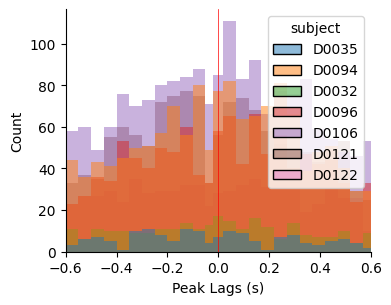

In [20]:
fig,ax = plt.subplots(1,1, figsize=(10*cm, 8*cm))

# sns.histplot(
#     oper_xcorrs[(oper_xcorrs.description=='Repeat') & (oper_xcorrs.phase=='Response')],
#     x='peak_lag_s',
#     hue='subject',
#     binwidth=0.05,
#     ax=ax,
# )

center = 0.02  # 2 ms (seconds)
edges = np.r_[
    np.arange(-0.6, -center, 0.05),
    -center, center,
    np.arange(center, 0.6 + 0.05, 0.05),
]

sns.histplot(data=oper_xcorrs[(oper_xcorrs.description=='Repeat') 
                              & (oper_xcorrs.phase=='Response')
                              & (oper_xcorrs.subject!='D0125')
                              & (~oper_xcorrs.source.isin(['D0106_LTAS2-3', 'D0125_LIA4-5',
                                                           'D0122_LFAI3-4', 'D0035_LAI2-3',
                                                           'D0125_LAI4-5', 'D0125_LAI3-4','D0125_LTAS3-4']))], 
             x="peak_lag_s", 
             hue="subject", bins=edges, ax=ax)

ax.set_xlim(-0.6, 0.6)
ax.set_xlabel('Peak Lags (s)')
sns.despine()
ax.axvline(x=0., color='r', lw=0.5)
# ax.set_xlim(0, 0.5)

In [21]:
oper_xcorrs[(oper_xcorrs.description=='Repeat') & (oper_xcorrs.phase=='Response')
                              & (oper_xcorrs.subject=='D0125')].source.unique()

array(['D0125_LIA3-4', 'D0125_LTAS2-3'], dtype=object)

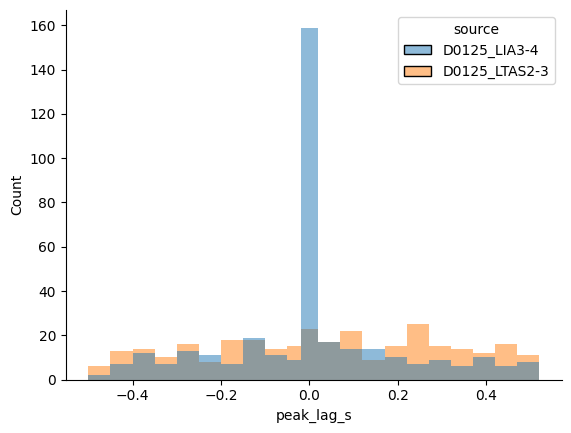

In [22]:
edges = np.r_[
    np.arange(-0.5, -center, 0.05),
    -center, center,
    np.arange(center, 0.5 + 0.05, 0.05),
]

sns.histplot(data=oper_xcorrs[(oper_xcorrs.description=='Repeat') & (oper_xcorrs.phase=='Response')
                              & (oper_xcorrs.subject=='D0125')], 
             x="peak_lag_s", 
             hue="source", bins=edges)

sns.despine()

In [23]:
oper_xcorrs[(oper_xcorrs.description=='Repeat') & (oper_xcorrs.phase=='Stimulus')
                              & (oper_xcorrs.subject=='D0106')]

,trial,source,target,source_roi,source_label,source_x,source_y,source_z,target_roi,target_label,target_x,target_y,target_z,peak_val,peak_lag_s,subject,phase,description,band,task
11,0,D0106_LAI1-2,D0106_LTAS3-4,INS,ctx_lh_G_insular_short,-33.921272,12.127291,-24.181028,IFG,ctx_lh_G_front_inf-Opercular,-47.882854,5.629037,-7.528778,0.016834,-0.345703,D0106,Stimulus,Repeat,highgamma,PictureNaming
12,0,D0106_LAI1-2,D0106_LTAS4-5,INS,ctx_lh_G_insular_short,-33.921272,12.127291,-24.181028,IFG,ctx_lh_G_front_inf-Opercular,-52.173326,4.333749,-8.364291,0.022845,-0.326172,D0106,Stimulus,Repeat,highgamma,PictureNaming
29,0,D0106_LAI2-3,D0106_LTAS3-4,INS,ctx_lh_G_insular_short,-33.563091,14.225522,-20.688729,IFG,ctx_lh_G_front_inf-Opercular,-47.882854,5.629037,-7.528778,0.016372,0.531738,D0106,Stimulus,Repeat,highgamma,PictureNaming
30,0,D0106_LAI2-3,D0106_LTAS4-5,INS,ctx_lh_G_insular_short,-33.563091,14.225522,-20.688729,IFG,ctx_lh_G_front_inf-Opercular,-52.173326,4.333749,-8.364291,0.017750,-0.272461,D0106,Stimulus,Repeat,highgamma,PictureNaming
47,0,D0106_LAI3-4,D0106_LTAS3-4,INS,ctx_lh_G_insular_short,-33.183625,16.435040,-16.995012,IFG,ctx_lh_G_front_inf-Opercular,-47.882854,5.629037,-7.528778,0.012075,-0.772949,D0106,Stimulus,Repeat,highgamma,PictureNaming
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14268,79,D0106_LAI3-4,D0106_LTAS4-5,INS,ctx_lh_G_insular_short,-33.183625,16.435040,-16.995012,IFG,ctx_lh_G_front_inf-Opercular,-52.173326,4.333749,-8.364291,0.022400,0.289551,D0106,Stimulus,Repeat,highgamma,PictureNaming
14285,79,D0106_LAI7-8,D0106_LTAS3-4,INS,ctx_lh_G_insular_short,-31.580150,25.718391,-1.414454,IFG,ctx_lh_G_front_inf-Opercular,-47.882854,5.629037,-7.528778,0.015337,-0.052734,D0106,Stimulus,Repeat,highgamma,PictureNaming
14286,79,D0106_LAI7-8,D0106_LTAS4-5,INS,ctx_lh_G_insular_short,-31.580150,25.718391,-1.414454,IFG,ctx_lh_G_front_inf-Opercular,-52.173326,4.333749,-8.364291,0.016149,-0.734375,D0106,Stimulus,Repeat,highgamma,PictureNaming
14339,79,D0106_LTAS1-2,D0106_LTAS3-4,INS,ctx_lh_G_insular_short,-39.301917,8.219612,-5.857753,IFG,ctx_lh_G_front_inf-Opercular,-47.882854,5.629037,-7.528778,0.016538,0.577637,D0106,Stimulus,Repeat,highgamma,PictureNaming
